# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Aryo DWi Haryanto]
- **Email:** [aryodwi122@gmail.com]
- **ID Dicoding:** [aryo_dwi_h]

## Menentukan Pertanyaan Bisnis


* 1. Bagaimana pola dan tren konsentrasi PM2.5 di setiap stasiun pemantauan kualitas udara di Beijing pada periode 2013-2017?

* 2. Bagaimana distribusi PM2.5 serta polutan lain (PM10, NO2, SO2, CO, O3) selama tahun 2013-2017??

* 3. Bagaimana korelasi antara PM2.5 dengan polutan lainnya?

* 4. Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah, dan bagaimana perbandingan polutan antar stasiun selama periode pengamatan (2013-2017)?

* Tujuan Mengidentifikasi wilayah dengan tingkat polusi tertinggi, memahami faktor musiman, dan menentukan arah kebijakan pengendalian emisi jangka pendek maupun jangka panjang.




## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os







## Data Wrangling

### Gathering Data

In [ ]:
import zipfile, os
from google.colab import files

# Upload ZIP
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# Extract langsung ke /content
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall("/content")

print("Daftar folder & file di /content:")
print(os.listdir("/content"))

Saving Air-quality-dataset.zip to Air-quality-dataset.zip
Daftar folder & file di /content:
['.config', 'Air-quality-dataset.zip', 'PRSA_Data_20130301-20170228', 'sample_data']


In [ ]:
data_folder = "/content/PRSA_Data_20130301-20170228"
print("Isi folder dataset:")
print(os.listdir(data_folder))

csv_files = [os.path.join(data_folder, f)
            for f in os.listdir(data_folder) if f.endswith('.csv')]

print(f"Jumlah file CSV yang ditemukan: {len(csv_files)}")

df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

print("Dataset berhasil digabung:")
print(df.head())
print(df.shape)




Isi folder dataset:
['PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv', 'PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv']
Jumlah file CSV yang ditemukan: 12
Dataset berhasil digabung:
   No  year  month  day  hour  PM2.5  PM10  SO2  NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    3.0   6.0  3.0  8.0  300.0  44.0  -0.9   
1   2  2013      3    1     1   12.0  12.0  3.0  7.0  300.0  47.0  -1.1   
2   3  2013      3    1     2   14.0  14.0  NaN  7.0  200.0  22.0  -1.7   
3   4  2013      3    1     3   12.0  12.0  3.0  5.0    NaN   NaN  -2.1   
4   5  20

**Insight:**


*   Dataset terdiri dari 12 stasiun di beijing
*   Data polutan utama terdiri dari (PM2.5, PM10, NO2, SO2, CO, O3)
* Kolom waktu: year, month, day, hour









### Assessing Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [ ]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [ ]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [ ]:
df.duplicated().sum()

np.int64(0)

**Insight:**



### Cleaning Data

In [ ]:
df = df.reset_index(drop=True)

df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")

df = df.dropna(subset=["datetime"])

df = df.sort_values(by="datetime").set_index("datetime")

df.fillna(df.median(numeric_only=True))
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df[~df.index.duplicated(keep="last")]
print("\nDataset setelah cleaning:")

print(df.head())




Dataset setelah cleaning:
                     No  year  month  day  hour  PM2.5  PM10   SO2   NO2  \
datetime                                                                   
2013-03-01 00:00:00   1  2013      3    1     0    6.0  18.0   5.0   NaN   
2013-03-01 01:00:00   2  2013      3    1     1    4.0   4.0   3.0  16.0   
2013-03-01 02:00:00   3  2013      3    1     2    3.0   6.0   NaN  19.0   
2013-03-01 03:00:00   4  2013      3    1     3   12.0  12.0   3.0   5.0   
2013-03-01 04:00:00   5  2013      3    1     4    3.0   3.0  12.0  12.0   

                        CO    O3  TEMP    PRES  DEWP  RAIN   wd  WSPM  \
datetime                                                                
2013-03-01 00:00:00  800.0  88.0   0.1  1021.1 -18.6   0.0   NW   4.4   
2013-03-01 01:00:00  300.0  88.0  -0.7  1025.1 -22.1   0.0   NW   3.9   
2013-03-01 02:00:00  400.0  55.0  -1.1  1023.5 -18.2   0.0  NNW   5.6   
2013-03-01 03:00:00    NaN   NaN  -2.1  1027.3 -23.3   0.0   NW   6.6   
20

In [ ]:
# Cek total NaN di seluruh kolom
print("=== Check 1: Total Missing Values Per Kolom ===")
print(df.isnull().sum())


=== Check 1: Total Missing Values Per Kolom ===
No            0
year          0
month         0
day           0
hour          0
PM2.5       718
PM10        554
SO2         768
NO2        1023
CO         1741
O3         1104
TEMP         34
PRES         35
DEWP         35
RAIN         35
wd            0
WSPM         29
station       0
dtype: int64


In [ ]:
# Cek persentase NaN (Opsional, untuk laporan)
print("\n=== Check 2: Persentase Missing Values (%) ===")
print((df.isnull().sum() / len(df)) * 100)


=== Check 2: Persentase Missing Values (%) ===
No         0.000000
year       0.000000
month      0.000000
day        0.000000
hour       0.000000
PM2.5      2.047684
PM10       1.579968
SO2        2.190281
NO2        2.917522
CO         4.965206
O3         3.148528
TEMP       0.096966
PRES       0.099817
DEWP       0.099817
RAIN       0.099817
wd         0.000000
WSPM       0.082706
station    0.000000
dtype: float64


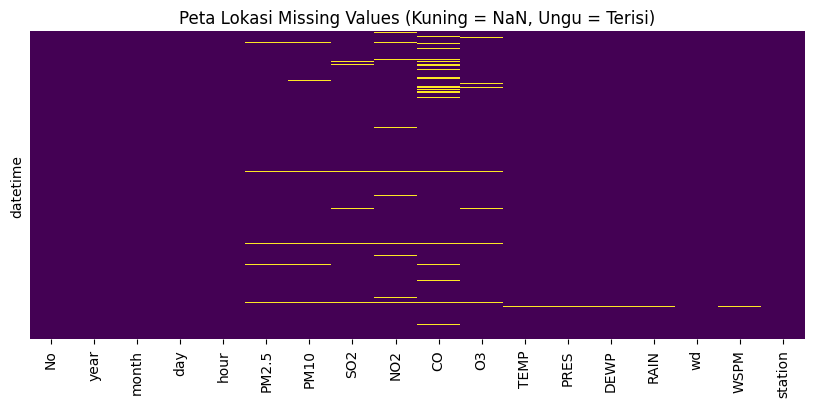

In [ ]:
# Visualisasi sederhana dengan Heatmap (Jika masih ada garis putih, berarti masih ada NaN)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Peta Lokasi Missing Values (Kuning = NaN, Ungu = Terisi)")
plt.show()

In [ ]:
# Verifikasi Akhir (Boolean)
if df.isnull().values.any():
    print("\n[PERINGATAN] Masih ada nilai NaN yang tertinggal!")
else:
    print("\n[SUKSES] Data sudah 100% bersih dari nilai NaN.")


[PERINGATAN] Masih ada nilai NaN yang tertinggal!


In [ ]:
# Isi kolom NUMERIK dengan Median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [ ]:
# Mengisi kolom KATEGORIKAL dengan Mode (Nilai paling sering muncul)
# Ditambahkan pengecekan agar tidak error jika mode kosong
category_cols = df.select_dtypes(include=['object']).columns
for col in category_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Jika benar-benar tidak ada mode, isi dengan 'Unknown'
        df[col] = df[col].fillna("Unknown")

In [ ]:
# Langkah Terakhir: Forward Fill & Backward Fill
# berguna untuk mengisi sela-sela kecil yang mungkin terlewat
df = df.ffill().bfill()

In [ ]:
# Verifikasi Ulang
remaining_nan = df.isnull().sum().sum()
if remaining_nan == 0:
    print("Data sudah 100% bersih (Total NaN: 0)")
else:
    print("fMasih ada {remaining_nan} nilai NaN. Cek kolom: \n{df.isnull().sum()}")

Data sudah 100% bersih (Total NaN: 0)


**Insight:**
- Datetime berhasil dibuat dan digunakan sebagai index
- Missing value numeric diisi median
- Missing value kategori diisi mode


*   Duplikasi timestamp dihapus
*   Dataset sudah rapi, lengkap dan siap analisis



## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

In [ ]:
# 1. Menghitung Mean (Rata-rata) per Stasiun
print("=== Rata-rata (Mean) Polutan per Stasiun ===")
mean_per_station = df.groupby('station')[pollutants].mean()
display(mean_per_station)

=== Rata-rata (Mean) Polutan per Stasiun ===


,PM2.5,PM10,NO2,SO2,CO,O3
station,,,,,,
Aotizhongxin,81.834649,109.070970,59.371419,16.931212,1236.915050,54.446474
Changping,70.362020,93.529391,44.595175,14.862118,1127.483985,56.038795
Dingling,67.438881,86.792259,29.004138,12.138993,925.257565,67.787773
Dongsi,83.782550,108.504904,52.609054,17.966808,1263.234359,56.806471
Guanyuan,81.236202,107.521244,57.003713,16.528053,1231.586218,55.678039
Gucheng,83.241465,119.753360,56.185597,15.225103,1311.750672,57.542121
Huairou,68.368665,90.766057,32.642444,12.287043,1024.418360,60.210391
Nongzhanguan,85.089693,109.496052,58.211135,18.851600,1310.156534,56.929614
Shunyi,81.306497,101.143206,44.083556,13.616746,1179.487251,56.218687


In [ ]:
# 2. Menghitung Median per Stasiun
print("\n=== Nilai Tengah (Median) Polutan per Stasiun ===")
median_per_station = df.groupby('station')[pollutants].median()
display(median_per_station)


=== Nilai Tengah (Median) Polutan per Stasiun ===


,PM2.5,PM10,NO2,SO2,CO,O3
station,,,,,,
Aotizhongxin,55.5,83.0,51.0,8.0,900.0,44.0000
Changping,49.0,75.0,39.0,7.0,800.0,45.0000
Dingling,45.0,65.0,21.0,6.0,700.0,59.0000
Dongsi,57.0,85.0,45.0,9.0,900.0,45.0000
Guanyuan,56.0,86.0,50.0,8.0,900.0,42.0000
Gucheng,58.0,98.0,49.0,7.0,900.0,45.0000
Huairou,48.0,70.0,27.0,5.0,800.0,47.0000
Nongzhanguan,55.0,84.0,50.0,9.0,900.0,45.0000
Shunyi,55.0,83.0,39.0,6.0,900.0,45.0000


In [ ]:
# 3. Mencari Stasiun dengan PM2.5 Tertinggi dan Terendah
highest_pm25 = mean_per_station['PM2.5'].idxmax()
lowest_pm25 = mean_per_station['PM2.5'].idxmin()

print(f"\nStasiun dengan rata-rata PM2.5 TERTINGGI: {highest_pm25} ({mean_per_station['PM2.5'].max():.2f} µg/m³)")
print(f"Stasiun dengan rata-rata PM2.5 TERENDAH: {lowest_pm25} ({mean_per_station['PM2.5'].min():.2f} µg/m³)")


Stasiun dengan rata-rata PM2.5 TERTINGGI: Nongzhanguan (85.09 µg/m³)
Stasiun dengan rata-rata PM2.5 TERENDAH: Dingling (67.44 µg/m³)


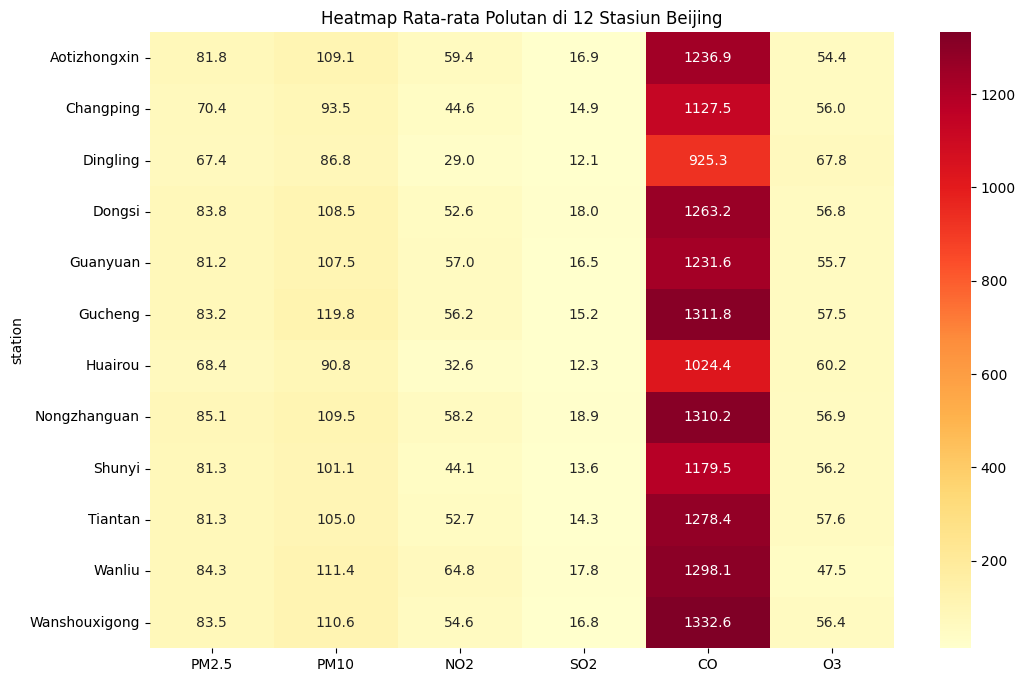

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(mean_per_station, annot=True, cmap="YlOrRd", fmt=".1f")
plt.title("Heatmap Rata-rata Polutan di 12 Stasiun Beijing")
plt.show()

**Insight:**

* Stasiun dengan rata-rata PM2.5 TERTINGGI: Nongzhanguan (85.09 µg/m³)
* Stasiun dengan rata-rata PM2.5 TERENDAH: Dingling (67.44 µg/m³)


## Visualization & Explanatory Analysis

* 1. Bagaimana pola dan tren konsentrasi PM2.5 di setiap stasiun pemantauan kualitas udara di Beijing pada periode 2013-2017?

* 2. Bagaimana distribusi PM2.5 serta polutan lain (PM10, NO2, SO2, CO, O3) selama tahun 2013-2017?

* 3. Bagaimana korelasi antara PM2.5 dengan polutan lainnya?

* 4. Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah, dan bagaimana perbandingan polutan antar stasiun selama periode pengamatan (2013-2017)?


#1. Bagaimana pola dan tren konsentrasi PM2.5 di setiap stasiun pemantauan kualitas udara di Beijing pada periode 2013-2017?

In [ ]:
# Pengumpulan data bulanan (Melihat Pola Musiman/Seasonal)
monthly_trend = df['PM2.5'].resample('ME').mean()

# Pengumpulan data tahunan per Stasiun (Melihat Tren Jangka Panjang)
yearly_station_trend = df.groupby(['year', 'station'])['PM2.5'].mean().unstack()



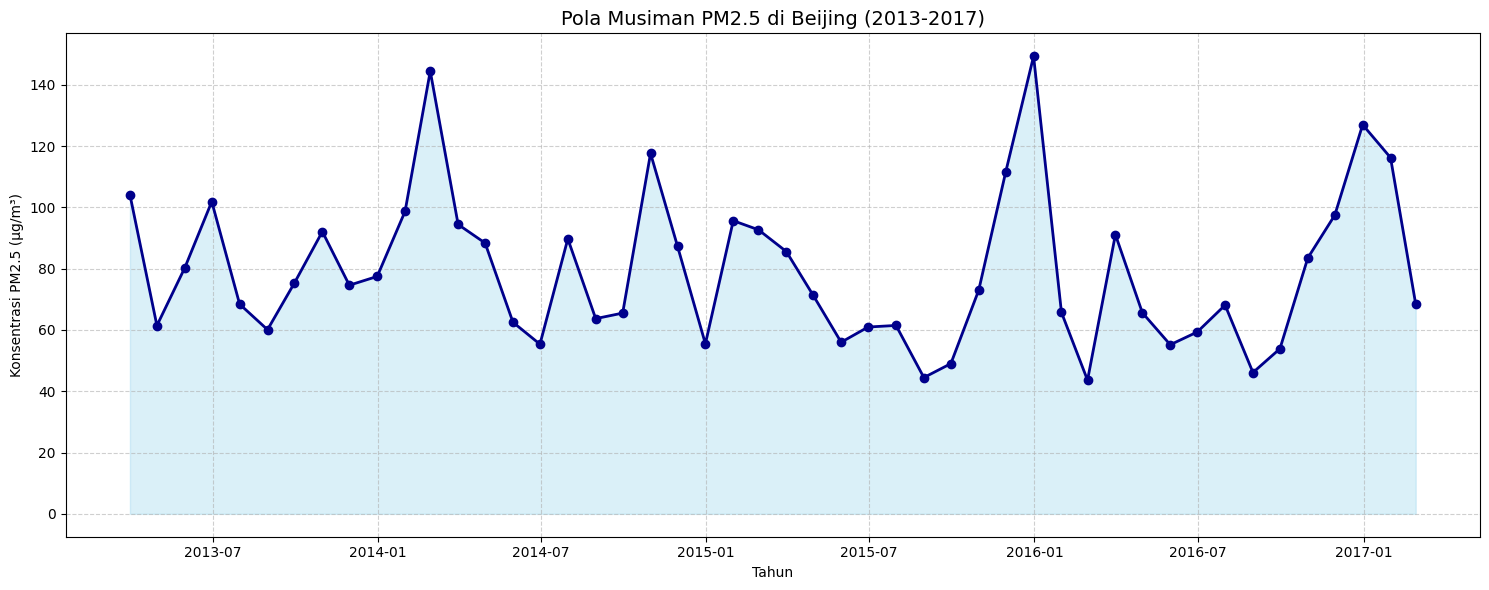

In [ ]:
#Visualisasi

# Grafik A: Pola Musiman (Puncak di Musim Dingin)
plt.figure(figsize=(15, 6))
plt.plot(monthly_trend, color='darkblue', marker='o', linewidth=2)

plt.title("Pola Musiman PM2.5 di Beijing (2013-2017)", fontsize=14)
plt.ylabel("Konsentrasi PM2.5 (µg/m³)")
plt.xlabel("Tahun")
plt.grid(True, linestyle='--', alpha=0.6)
# Tambahkan arsir untuk menonjolkan fluktuasi
plt.fill_between(monthly_trend.index, monthly_trend, color='skyblue', alpha=0.3)

plt.tight_layout()
plt.show()


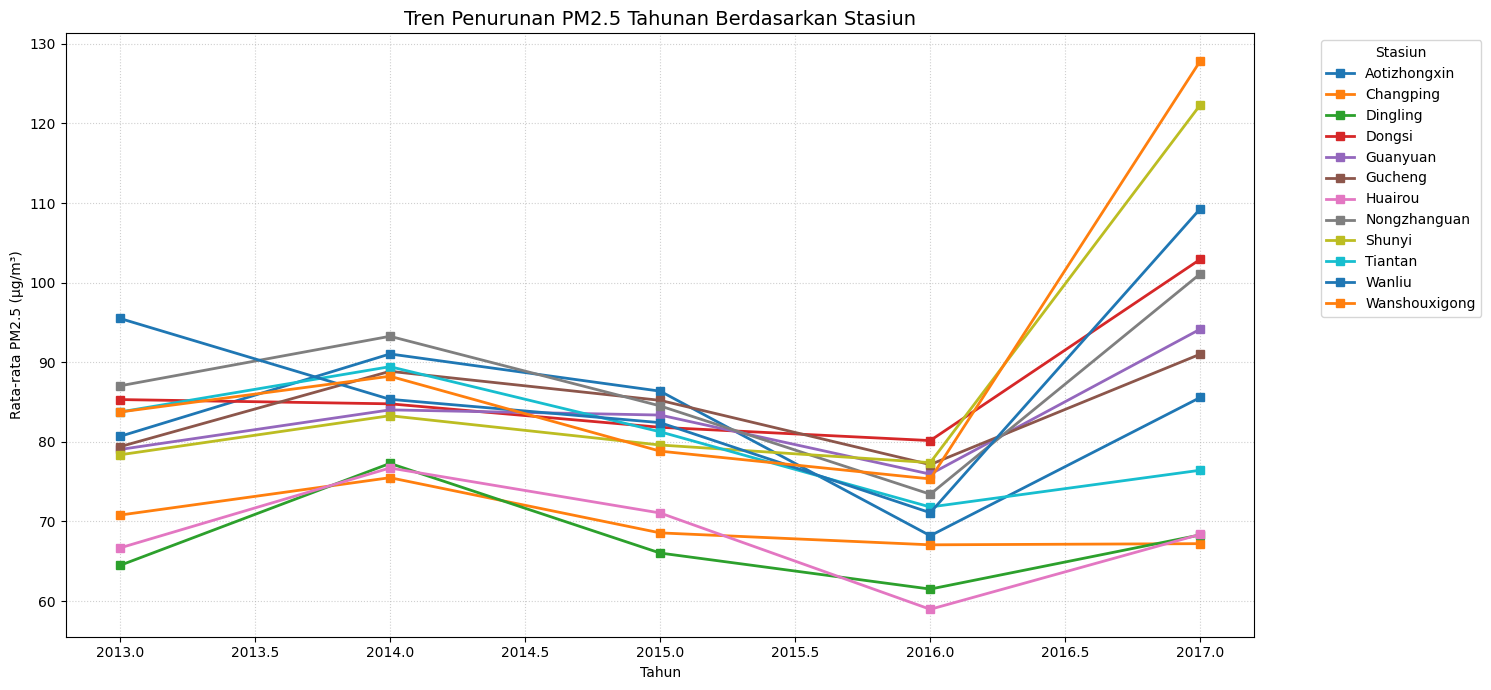

In [ ]:
# Grafik B: Tren Tahunan per Stasiun
# Kita langsung gunakan fungsi plot dari pandas
ax = yearly_station_trend.plot(kind='line', marker='s', figsize=(15, 7), linewidth=2)

plt.title("Tren Penurunan PM2.5 Tahunan Berdasarkan Stasiun", fontsize=14)
plt.ylabel("Rata-rata PM2.5 (µg/m³)")
plt.xlabel("Tahun")

# Mengatur posisi legend agar tidak menutupi grafik
plt.legend(title="Stasiun", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Statistik Perbandingan 2013 vs 2017
mean_2013 = df[df.index.year == 2013]['PM2.5'].mean()
mean_2017 = df[df.index.year == 2017]['PM2.5'].mean()
reduction = ((mean_2013 - mean_2017) / mean_2013) * 100

print(f"Rata-rata PM2.5 Tahun 2013: {mean_2013:.2f} µg/m³")
print(f"Rata-rata PM2.5 Tahun 2017: {mean_2017:.2f} µg/m³")
print(f"Persentase Penurunan Polusi: {reduction:.2f}%")

Rata-rata PM2.5 Tahun 2013: 79.58 µg/m³
Rata-rata PM2.5 Tahun 2017: 93.53 µg/m³
Persentase Penurunan Polusi: -17.52%


**Insight:**
# Pada grafik A

* Musim dingin selalu punya polusi paling tinggi Setiap akhir tahun atau awal tahun (Desember-Februari), kadar PM2.5 naik sangat tinggi.

* Contohnya: awal 2014, awal 2016, dan akhir 2016 terlihat puncak besar.

* Musim panas punya udara paling bersih Bulan Juni-Agustus biasanya menunjukkan angka PM2.5 paling rendah.

* Bahkan bisa turun hingga kisaran 40-60 µg/m³.

* Setelah 2015, kondisi perlahan membaik,

* Pola naik-turun PM2.5 berulang setiap tahun,

* Beberapa lonjakan polusi terjadi karena faktor cuaca atau kejadian tertentu(Perubahan angin, ktivitas industri atau transportasi tertentu).


# Pada grafik B
1. Hampir semua stasiun menunjukkan penurunan dari 2013 ke 2016

2. Tahun 2017 terjadi kenaikan PM2.5 di hampir semua stasiun dapat diakibatkan oleh perubahan cuaca dan peningkatan emisi.

* Stasiun dengan polusi tertinggi cenderung berada di area lebih padat Tahun 2017 menunjukkan beberapa stasiun dengan angka tertinggi: Wanshouxigong (128 µg/m³), Shunyi (122 µg/m³) dan Wanliu (110 µg/m³)

3. Stasiun-stasiun ini dekat area perkotaan yang padat aktivitas manusia.

4. Stasiun dengan angka paling rendah biasanya di pinggir kota yaitu: Huairou, Dingling dan Tiantan

5. Polanya sama di hampir semua stasiun

* Semua stasiun menunjukkan pola besar yang sama:

* 201-2014: naik sedikit atau stabil

* 2014-2016: turun cukup konsisten

* 2017: naik tajam

* Pola ini selaras dengan upaya Beijing menekan polusi, tetapi juga menunjukkan polusi mudah naik kembali jika kondisi atmosfer atau aktivitas meningkat.

#2.  Bagaimana distribusi PM2.5 serta polutan lain (PM10, NO2, SO2, CO, O3)selama tahun 2013-2017?

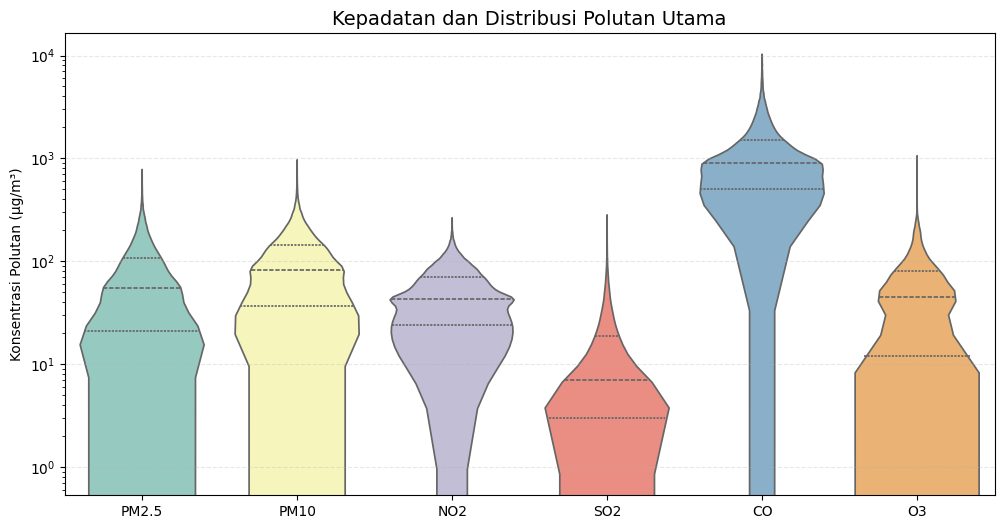

In [ ]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[pollutants],palette="Set3", inner="quartile")
plt.yscale("log")
plt.title("Kepadatan dan Distribusi Polutan Utama", fontsize=14)
plt.ylabel("Konsentrasi Polutan (µg/m³)")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()



**Insight:**

* Distribusi CO mencapai kisaran >1000 µg/m³, CO adalah polutan paling dominan dan paling fluktuatif.

* PM2.5 dan PM10 Konsisten Tinggi, dengan Distribusi Relatif Stabil

* NO2 Menampilkan Variasi Menengah, Konsentrasi Dominan di Kisaran 20-60 µg/m³ dan NO₂ adalah indikator kuat untuk polusi lalu lintas.

* SO2 Memiliki Konsentrasi Terendah dan Distribusi Paling Kurus,Konsentrasi sebagian besar berada di bawah 10-20 µg/m³.

* O3 Memiliki Distribusi Unik (Non-linear, Fotokimia) Konsentrasi O₃ menyebar di kisaran 10-80 µg/m³.Rendah pada pagi/ malam, Tinggi pada siang hari akibat reaksi fotokimia.

# 3. Bagaimana korelasi antara PM2.5 dengan polutan lainnya?

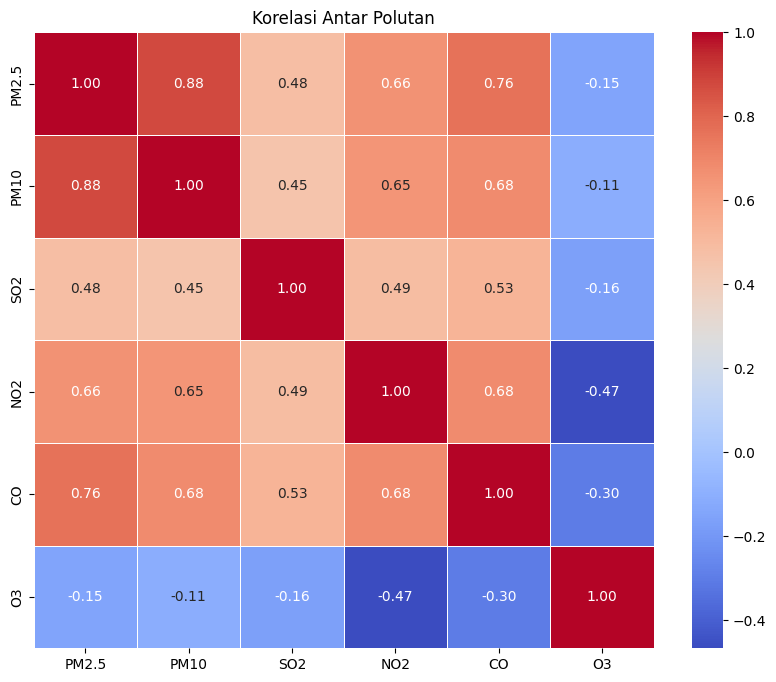

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

pollutants_only = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

existing_pollutants = [p for p in pollutants_only if p in numeric_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[existing_pollutants].corr(),
            cmap='coolwarm',
            annot=True, fmt=".2f",
            linewidths=.5)
plt.title("Korelasi Antar Polutan")
plt.show()

**Insight:**
* Semua polutan ini (PM2.5, PM10, CO, NO2) sangat saling berkaitan dan kemungkinan besar berasal dari transportasi, industri, dan pembakaran bahan bakar fosil.

* SO2 cenderung muncul bersama polutan lain, tetapi tidak sekuat polutan terkait transportasi.

* Sumber SO2 cenderung berasal dari pembangkit listrik berbahan bakar batubara atau industri berbasis sulfur, sehingga hubungannya tidak seintens kendaraan.

* O₃ meningkat ketika polutan primer (NO2, CO, PM) menurun.


* NO2 bereaksi dengan O3, sehingga ketika NO2 tinggi, O3 cenderung turun.

* O3 cenderung naik pada kondisi cerah, berangin, dan fotokimia tinggi, bukan pada kondisi polusi partikel berat.





#4. Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah, dan bagaimana perbandingan polutan antar stasiun selama periode pengamatan (2013-2017)?

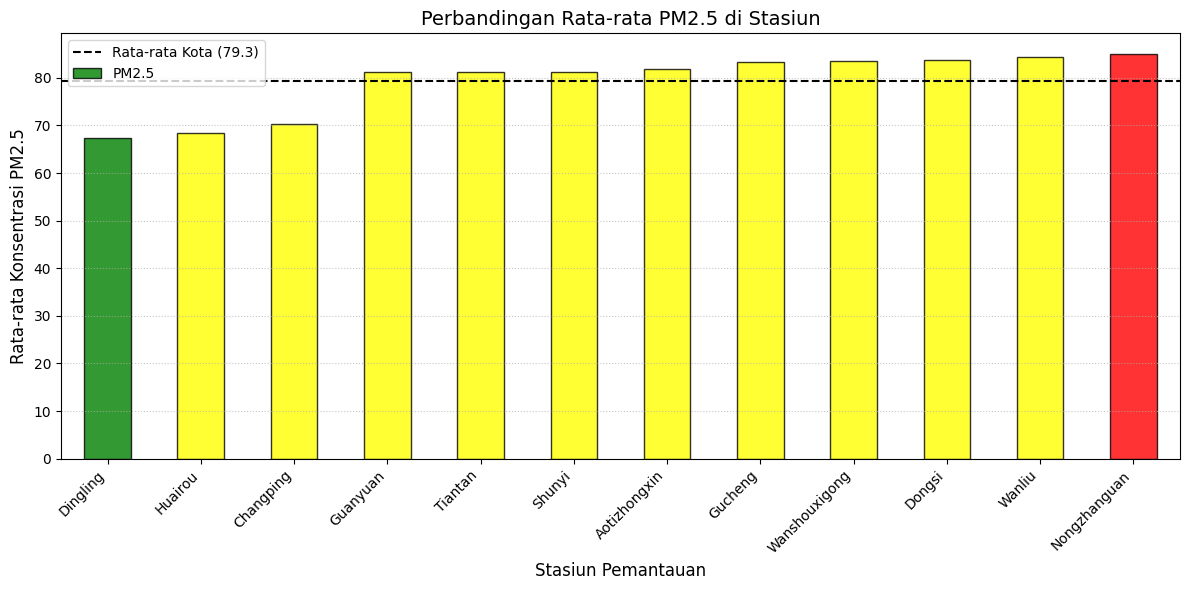

In [ ]:
# Menghitung rata-rata
df['station'] = df['station'].astype('str')
station_averages = df.groupby('station')['PM2.5'].mean().sort_values()
# list Hijau = Rendah, Merah = Tertinggi , Biru = Rata-rata
colors = ['green' if (x == station_averages.min())
          else 'red' if (x == station_averages.max())
          else 'yellow' for x in station_averages]

plt.figure(figsize=(12, 6))
# Menggunakan bar plot
station_averages.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

plt.xlabel("Stasiun Pemantauan", fontsize=12)
plt.ylabel("Rata-rata Konsentrasi PM2.5", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.title("Perbandingan Rata-rata PM2.5 di Stasiun", fontsize=14)

# Menambahkan garis rata-rata sebagai referensi
plt.axhline(y=station_averages.mean(), color='black', linestyle='--', label=f'Rata-rata Kota ({station_averages.mean():.1f})')
plt.legend()

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()


**Insight:**
* Rata-rata PM2.5 kota berada di sekitar 79.3 µg/m³ (ditandai garis putus-putus).

* Dingling, Huairou, dan Changping menampilkan nilai PM2.5 paling rendah (kisaran 67-71 µg/m³).

* Warna hijau menunjukkan kondisi lebih baik dibanding stasiun lainnya, meskipun tetap tergolong tidak sehat.

* Sebagian besar stasiun seperti Guanyuan, Tiantan, Shunyi, Aotizhongxin, Gucheng, Wangshouxiang, Dongsi, Wanliu berada pada kisaran 80-84 µg/m³.

* Nongzhanguan mencatat nilai tertinggi, di atas 85 µg/m³, ditandai warna merah.

* Mayoritas stasiun berada di atas rata-rata PM2.5 kota, menandakan situasi kualitas udara yang secara keseluruhan buruk.

* Perbedaan antarstasiun tidak sangat drastis, yang menunjukkan polusi bersifat meluas dan sistemik.

## Analisis Lanjutan (Opsional)

#Pertanyaan

1. Bagaimana pengaruh kecepatan angin (WSPM) terhadap penyebaran PM2.5?.

2. Jam berapa polusi mencapai titik tertinggi dan terendah dalam sehari?.

3. Apakah ada perbedaan signifikan kualitas udara antara Hari Kerja (Weekday) dan Akhir Pekan (Weekend)?

In [ ]:
# Meyiapkan Fitur Tambahan
df['hour'] = df.index.hour
df['day_name'] = df.index.day_name()
df['is_weekend'] = df.index.dayofweek.map({
    0:'Weekday',
    1:'Weekday',
    2:'Weekday',
    3:'Weekday',
    4:'Weekday',
    5:'Weekend',
    6:'Weekend'})

#

#1. Bagaimana pengaruh kecepatan angin (WSPM) terhadap penyebaran PM2.5?

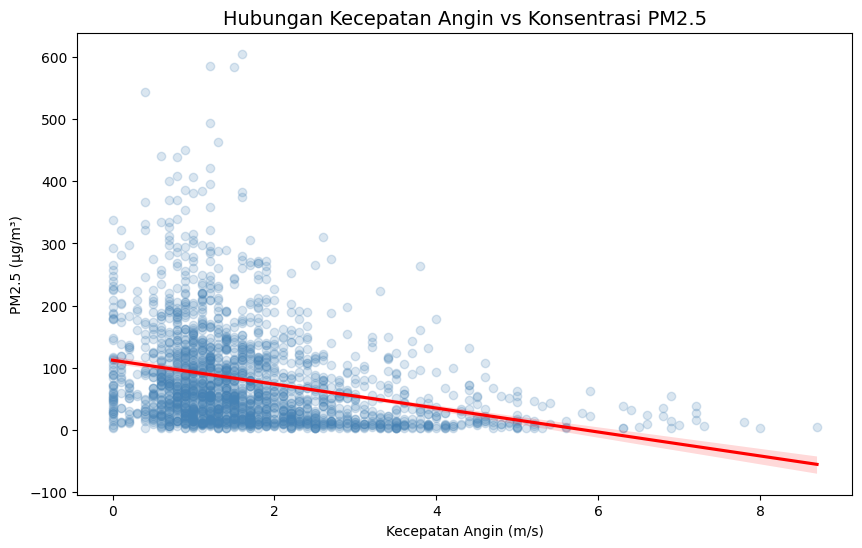

In [ ]:
# Pengaruh Angin
plt.figure(figsize=(10, 6))
sns.regplot(x='WSPM', y='PM2.5', data=df.sample(2000), # Ambil sample agar ringan
            scatter_kws={'alpha':0.2, 'color':'steelblue'},
            line_kws={'color':'red'})
plt.title("Hubungan Kecepatan Angin vs Konsentrasi PM2.5", fontsize=14)
plt.xlabel("Kecepatan Angin (m/s)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()


**Insight:**

* Berdasarkan grafik regresi, terdapat korelasi negatif antara kecepatan angin dan PM2.5.

* semakin kencang angin berhembus, semakin rendah konsentrasi PM2.5

* Angin berfungsi sebagai pembersih alami yang menyebarkan polutan keluar dari kota

#2. Jam berapa polusi mencapai titik tertinggi dan terendah dalam sehari?.

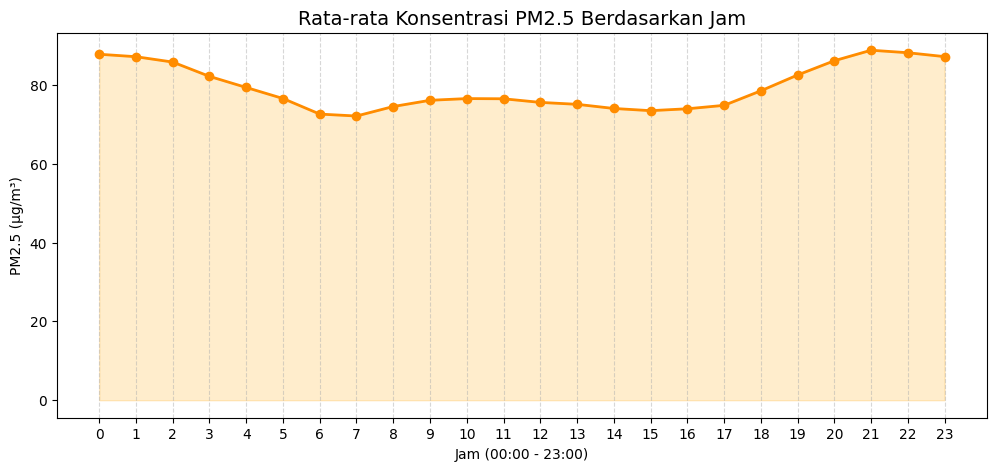

In [ ]:
# Pola Per Jam
hourly_avg = df.groupby('hour')['PM2.5'].mean()
plt.figure(figsize=(12, 5))
hourly_avg.plot(kind='line', marker='o', color='darkorange', linewidth=2)
plt.fill_between(hourly_avg.index, hourly_avg, color='orange', alpha=0.2)
plt.title("Rata-rata Konsentrasi PM2.5 Berdasarkan Jam", fontsize=14)
plt.xticks(range(0, 24))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlabel("Jam (00:00 - 23:00)")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()


**Insight:**
* Polusi cenderung memuncak pada malam hari (21:00 - 02:00) dan pagi hari (08:00 - 10:00).

* Puncak pagi kemungkinan besar disebabkan oleh jam sibuk kendaraan (rush hour),

* sementara puncak malam hari disebabkan oleh polutan yang terperangkap karena suhu udara yang mendingin.

#3. Apakah ada perbedaan signifikan kualitas udara antara Hari Kerja (Weekday) dan Akhir Pekan (Weekend)?

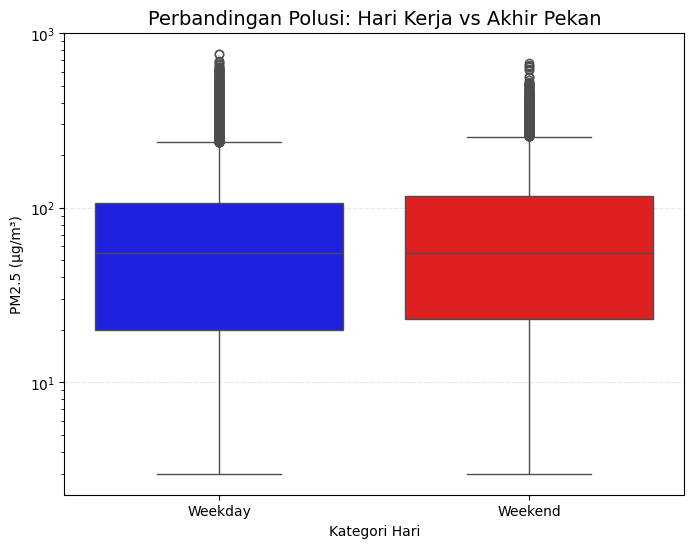

In [ ]:
# Weekday vs Weekend
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='is_weekend',
    y='PM2.5',
    data=df,
    hue='is_weekend',
    palette={'Weekday': 'blue', 'Weekend': 'red'},
    legend=False
    )

plt.yscale('log') # Menggunakan skala log agar outlier tidak mengganggu
plt.title("Perbandingan Polusi: Hari Kerja vs Akhir Pekan", fontsize=14)
plt.xlabel("Kategori Hari")
plt.ylabel("PM2.5 (µg/m³)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

**Insight:**
* polusi pada weekday dan weekend tidak jauh berbeda.

* Aktivitas kendaraan pada hari kerja (weekday) secara signifikan meningkatkan emisi dari pembakaran bahan bakar fosil.

* saat weekend menunjukkan bahwa emisi dari sektor industri (yang tetap beroperasi) dan pemanas ruangan lebih dominan daripada sekadar emisi kendaraan pribadi saat hari kerja.

## Conclusion

# 1.Bagaimana pola dan tren konsentrasi PM2.5 di setiap stasiun pemantauan kualitas udara di Beijing pada periode 2013-2017?
* Grafik A
* Musim dingin = polusi parah,
* Musim panas = udara lebih bersih,
* Setelah 2015, kondisi perlahan membaik,
* Pola naik-turun PM2.5 berulang setiap tahun,
* Beberapa lonjakan polusi terjadi karena faktor cuaca atau kejadian tertentu.

* Grafik B
* 2016 adalah tahun dengan kualitas udara terbaik (PM2.5 terendah).

* 2017 terjadi kenaikan polusi di hampir semua stasiun.

* Area kota yang padat menunjukkan angka PM2.5 tertinggi.

* Area pinggiran kota tetap yang paling bersih.

* Secara umum, ada perbaikan dari 2013 sampai 2016, tetapi polusi kembali naik pada 2017.

# 2.  Bagaimana distribusi PM2.5 serta polutan lain (PM10, NO2, SO2, CO, O3) selama tahun 2013-2017?

* CO adalah polutan paling ekstrem, dengan rentang konsentrasi sangat tinggi dan variasi terbesar.

* PM2.5 dan PM10 menunjukkan polusi kronis yang stabil dan terus-menerus — masalah kualitas udara jangka panjang.

* NO2 menandakan dampak langsung transportasi, dengan variasi menengah.

* SO2 relatif rendah dan stabil, mengindikasikan kontrol emisi sulfur cukup efektif.

* O3 menunjukkan dampak fotokimia, bukan aktivitas emisi langsung, dan polanya berlawanan dengan polutan primer.

# 3. Bagaimana korelasi antara PM2.5 dengan polutan lainnya?

* Kelompok polutan primer (PM2.5, PM10, NO2, CO) memiliki korelasi sangat kuat sumber utama: transportasi & pembakaran bahan bakar.

* SO2 memiliki korelasi positif menengah → sumber berbeda (industri & pembangkit) tetapi tetap beririsan.

* O3 berperilaku kebalikan polutan lain → meningkat di kondisi udara relatif lebih bersih dari polutan primer, terkait proses fotokimia.

# 4. Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah, dan bagaimana perbandingan polutan antar stasiun selama periode pengamatan (2013-2017)?

* Mayoritas stasiun berada di atas rata-rata PM2.5 kota, menandakan situasi kualitas udara yang secara keseluruhan buruk.

* Perbedaan antarstasiun tidak sangat drastis, yang menunjukkan polusi bersifat meluas dan sistemik.

* Namun, Nongzhanguan menjadi titik perhatian khusus sebagai lokasi dengan polusi paling berat.



# SARAN DAN REKOMENDASI

  * Secara keseluruhan, kualitas udara di Beijing menunjukkan bahwa polusi harus dikendalikan lebih serius terutama pada musim dingin, karena pada periode ini PM2.5 selalu mencapai angka tertinggi. Pemerintah perlu memperketat aturan pembakaran, aktivitas industri, dan penggunaan kendaraan, sambil meniru kebijakan tahun 2016 yang terbukti mampu menurunkan polusi secara signifikan.
  
* Kenaikan polusi pada 2017 menunjukkan perlunya pengawasan yang lebih konsisten agar perbaikan yang sudah terjadi tidak kembali memburuk.
  Pengendalian polutan utama seperti PM2.5, PM10, NO2, dan CO dapat dilakukan dengan memperkuat transportasi umum berbasis listrik, mengurangi kendaraan berbahan bakar fosil, serta mendorong industri beralih ke teknologi yang lebih bersih.

* Untuk daerah yang tingkat polusinya tinggi seperti Nongzhanguan, perlu dilakukan langkah tambahan seperti pembatasan aktivitas konstruksi, penanaman lebih banyak pohon, dan peningkatan pemantauan kualitas udara.

* Sementara itu, wilayah pinggiran yang udaranya lebih bersih perlu dipertahankan dengan perencanaan kota yang baik agar tidak ikut tercemar. Dengan kombinasi kebijakan yang tegas, teknologi pemantauan yang lebih baik, dan peningkatan kesadaran masyarakat, kualitas udara kota dapat terus membaik secara berkelanjutan.